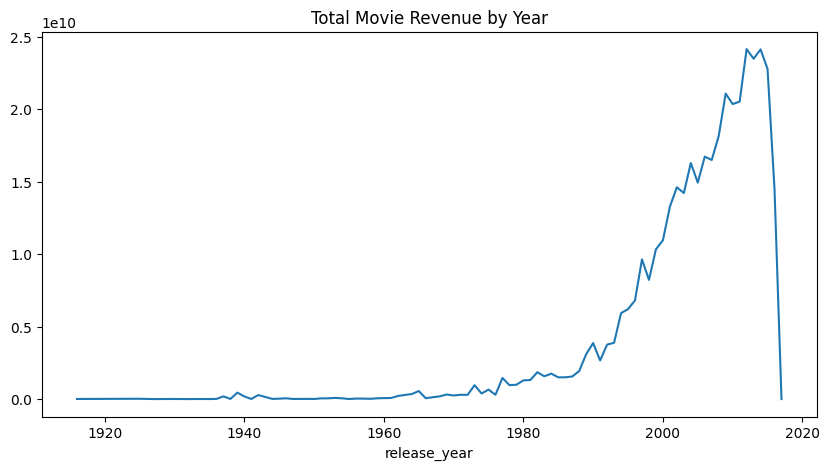

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.29737D+01    |proj g|=  9.28207D-01

At iterate    5    f=  2.23872D+01    |proj g|=  1.15197D-02

At iterate   10    f=  2.23814D+01    |proj g|=  2.85259D-03

At iterate   15    f=  2.23806D+01    |proj g|=  6.00911D-04

At iterate   20    f=  2.23804D+01    |proj g|=  1.07578D-04

At iterate   25    f=  2.23804D+01    |proj g|=  1.46297D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3     26     30      1     0     0   

/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/raimaazrafiislam/opt/miniconda3/envs/newenv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
 This problem is unconstrained.
/Users/raimaazrafiislam/opt/miniconda3

In [1]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('../data/movies.csv')

df["release_date"] = pd.to_datetime(df["release_date"])
df["release_month"] = df["release_date"].dt.month
df["release_year"] = df["release_date"].dt.year

revenue_by_year = df.groupby("release_year")["revenue"].sum()

revenue_by_year.plot(figsize=(10,5))
plt.title("Total Movie Revenue by Year")
plt.show()

model = SARIMAX(revenue_by_year, order=(1,1,1))
results = model.fit()

forecast = results.forecast(steps=5)

print(forecast)